In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew
import igraph
import os

pd.set_option("display.max_columns", 30)

In [3]:
# timestamp = "20250225_145621"
timestamp = "20250508_160635"
# Datasets - synthetic
## Transcriptomics
gexp_df = pd.read_csv(
    f"/home/scai/PhenPred/reports/vae/files/{timestamp}_imputed_transcriptomics.csv.gz",
    index_col=0,
)

## CRISPR-Cas9
cas9_df = pd.read_csv(
    f"/home/scai/PhenPred/reports/vae/files/{timestamp}_imputed_crisprcas9.csv.gz",
    index_col=0,
)

In [4]:
df_res_vae_annot = pd.read_csv(
    f"../reports/vae/crispr/{timestamp}_transcriptomics_crisprcas9_remove_latent_n3_no_tissue_standardizedTrue_annot.csv.gz"
)
df_res_vae_annot["log10fdr_orig"] = -np.log10(df_res_vae_annot["fdr_orig"])
df_res_vae_annot["log10fdr_vae"] = -np.log10(df_res_vae_annot["fdr_vae"])
df_res_vae_annot["diff_log10fdr"] = (
    df_res_vae_annot["log10fdr_vae"] - df_res_vae_annot["log10fdr_orig"]
)

df_res_vae_annot_filtered = df_res_vae_annot.query("fdr_vae < 0.05 and beta_vae > 0")

In [5]:
df_res_vae_annot_filtered = df_res_vae_annot_filtered[
    df_res_vae_annot_filtered["y_id"].isin(gexp_df.columns)
]

In [6]:
df_res_vae_annot_filtered.head()

,y_id,x_id,n_orig,beta_orig,lr_orig,covs_orig,pval_orig,fdr_orig,n_vae,beta_vae,lr_vae,covs_vae,pval_vae,fdr_vae,skew_orig,skew_mosa,target_detailed,target,entropy,log10fdr_orig,log10fdr_vae,diff_log10fdr
0,FAM50A,FAM50B,923.0,0.75825,775.49438,208.0,1.148490e-170,1.975632e-166,1523.0,0.62305,846.16667,211.0,4.953857e-186,1.802213e-182,-0.62729,-0.38142,No link; CRISPR not in network,-,0.82245,165.704294,181.744194,16.039900
1,DDX3X,DDX3Y,923.0,0.70104,628.13085,208.0,1.274517e-138,2.192424e-134,1523.0,0.54253,592.67442,211.0,6.564286e-131,2.388087e-127,0.54274,-0.18181,3,3,0.83160,133.659076,126.621950,-7.037126
2,DDX3X,USP9Y,923.0,0.66805,569.93911,208.0,5.788442e-126,9.957278e-122,1523.0,0.50986,522.08826,211.0,1.486670e-115,5.408505e-112,0.54274,-0.18181,3,3,0.83160,121.001859,111.266923,-9.734937
3,DDX3X,UTY,923.0,0.67039,566.34511,208.0,3.502334e-125,6.024714e-121,1523.0,0.50949,523.46762,211.0,7.449375e-116,2.710083e-112,0.54274,-0.18181,3,3,0.83160,120.220064,111.567017,-8.653046
4,EIF1AX,EIF1AY,923.0,0.69643,563.47514,208.0,1.474560e-124,2.536539e-120,1523.0,0.54443,528.78237,211.0,5.198192e-117,1.891102e-113,0.61340,-0.24279,1,1,0.83172,119.595758,112.723285,-6.872473


In [7]:
synlethdb_df = pd.read_csv("../data/gene_sl_gene.tsv", sep="\t")

In [8]:
synlethdb_df

,x:START_ID,x_type,x_name,x_source,y:END_ID,y_type,y_name,y_source,relation,:TYPE,rel_source,edge_index,cell_line,pubmed_id,cancer
0,537,Gene,ATP6AP1,NCBI,10988,Gene,METAP2,NCBI,SL,Gene_SL_Gene,CRISPR/CRISPRi,8606596,K562,31300006.0,NaN
1,23071,Gene,ERP44,NCBI,8883,Gene,NAE1,NCBI,SL,Gene_SL_Gene,GenomeRNAi,8606662,A375,23100467.0,NaN
2,2146,Gene,EZH2,NCBI,10793,Gene,ZNF273,NCBI,SL,Gene_SL_Gene,Computational Prediction,8606698,NaN,25171417.0,NaN
3,2064,Gene,ERBB2,NCBI,6608,Gene,SMO,NCBI,SL,Gene_SL_Gene,High Throughput,8606821,293T,28319113.0,NaN
4,596,Gene,BCL2,NCBI,90427,Gene,BMF,NCBI,SL,Gene_SL_Gene,Text Mining,8606921,NaN,19244105.0,melanoma_D008545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37938,4045,Gene,LSAMP,NCBI,5728,Gene,PTEN,NCBI,SL,Gene_SL_Gene,Computational Prediction,10415503,NaN,26427375.0,NaN
37939,1445,Gene,CSK,NCBI,2902,Gene,GRIN1,NCBI,SL,Gene_SL_Gene,High Throughput,10415631,TBD,29987050.0,NaN
37940,2971,Gene,GTF3A,NCBI,3146,Gene,HMGB1,NCBI,SL,Gene_SL_Gene,Computational Prediction,10415667,NaN,25171417.0,NaN
37941,9994,Gene,CASP8AP2,NCBI,3066,Gene,HDAC2,NCBI,SL,Gene_SL_Gene,Computational Prediction,10415697,NaN,25171417.0,NaN


In [9]:
# Step 1: Canonicalize pairs (sort alphabetically so A-B = B-A)
def canonicalize_pair(g1, g2):
    """Return tuple with genes in alphabetical order."""
    return tuple(sorted([g1, g2]))

# Your tested pairs (universe)
df_res_vae_annot["pair"] = df_res_vae_annot.apply(
    lambda r: canonicalize_pair(r["y_id"], r["x_id"]), axis=1
)

# Your nominated pairs (positive set)
df_res_vae_annot_filtered["pair"] = df_res_vae_annot_filtered.apply(
    lambda r: canonicalize_pair(r["y_id"], r["x_id"]), axis=1
)

# SynLethDB pairs
synlethdb_df["pair"] = synlethdb_df.apply(
    lambda r: canonicalize_pair(r["x_name"], r["y_name"]), axis=1
)

print(f"Canonicalized pairs created:")
print(f"  - Universe (all tested): {len(df_res_vae_annot)} pairs")
print(f"  - Nominated (filtered): {len(df_res_vae_annot_filtered)} pairs")
print(f"  - SynLethDB: {len(synlethdb_df)} pairs")

Canonicalized pairs created:
  - Universe (all tested): 29796518 pairs
  - Nominated (filtered): 22780 pairs
  - SynLethDB: 37943 pairs


In [10]:
# Step 2: Define sets
universe = set(df_res_vae_annot["pair"])  # All tested pairs
nominated = set(df_res_vae_annot_filtered["pair"])  # Your SL calls
synlethdb = set(synlethdb_df["pair"])

# Restrict SynLethDB to pairs in your universe
synlethdb_in_universe = synlethdb & universe

print(f"Set sizes:")
print(f"  - Universe (all tested): {len(universe):,} unique pairs")
print(f"  - Nominated (your SL calls): {len(nominated):,} unique pairs")
print(f"  - SynLethDB (total): {len(synlethdb):,} unique pairs")
print(f"  - SynLethDB in universe: {len(synlethdb_in_universe):,} unique pairs")
print(f"\nOverlap:")
print(f"  - Nominated & SynLethDB (in universe): {len(nominated & synlethdb_in_universe):,} pairs")

Set sizes:
  - Universe (all tested): 29,693,687 unique pairs
  - Nominated (your SL calls): 22,772 unique pairs
  - SynLethDB (total): 37,536 unique pairs
  - SynLethDB in universe: 9,571 unique pairs

Overlap:
  - Nominated & SynLethDB (in universe): 29 pairs


In [11]:
# Method 1: Fisher's Exact Test (Overlap Enrichment)
# Tests whether your nominated pairs are enriched for SynLethDB pairs compared to random chance
from scipy.stats import fisher_exact, hypergeom

a = len(nominated & synlethdb_in_universe)  # Both nominated AND in SynLethDB
b = len(nominated - synlethdb_in_universe)  # Nominated but NOT in SynLethDB
c = len(synlethdb_in_universe - nominated)  # In SynLethDB but NOT nominated
d = len(universe - nominated - synlethdb_in_universe)  # Neither

contingency = [[a, b], [c, d]]
odds_ratio, pvalue_fisher = fisher_exact(contingency, alternative="greater")

print("=" * 60)
print("Method 1: Fisher's Exact Test")
print("=" * 60)
print(f"\nContingency table:")
print(f"                     In SynLethDB    Not in SynLethDB")
print(f"  Nominated:         {a:>10,}       {b:>10,}")
print(f"  Not nominated:     {c:>10,}       {d:>10,}")
print(f"\nOdds ratio: {odds_ratio:.4f}")
print(f"P-value (one-sided, greater): {pvalue_fisher:.2e}")

# Method 2: Hypergeometric Test (equivalent framing)
M = len(universe)
n = len(synlethdb_in_universe)
N = len(nominated)
k = len(nominated & synlethdb_in_universe)

pvalue_hypergeom = hypergeom.sf(k - 1, M, n, N)  # P(X >= k)

print("\n" + "=" * 60)
print("Method 2: Hypergeometric Test")
print("=" * 60)
print(f"\nM (universe size): {M:,}")
print(f"n (SynLethDB in universe): {n:,}")
print(f"N (nominated): {N:,}")
print(f"k (overlap): {k:,}")
print(f"P-value (P(X >= k)): {pvalue_hypergeom:.2e}")

Method 1: Fisher's Exact Test

Contingency table:
                     In SynLethDB    Not in SynLethDB
  Nominated:                 29           22,743
  Not nominated:          9,542       29,661,373

Odds ratio: 3.9637
P-value (one-sided, greater): 1.19e-09

Method 2: Hypergeometric Test

M (universe size): 29,693,687
n (SynLethDB in universe): 9,571
N (nominated): 22,772
k (overlap): 29
P-value (P(X >= k)): 1.19e-09


In [12]:
# Method 3: Precision / Recall / F1
# Treats SynLethDB as "ground truth" (with caveats about incompleteness)

tp = len(nominated & synlethdb_in_universe)
fp = len(nominated - synlethdb_in_universe)
fn = len(synlethdb_in_universe - nominated)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 60)
print("Method 3: Precision / Recall / F1")
print("=" * 60)
print(f"\nTrue Positives (TP): {tp:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"\nPrecision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")
print("\n** Caveat: Low precision doesn't mean your novel pairs are wrong;")
print("   SynLethDB is incomplete and your discoveries may be valid. **")

Method 3: Precision / Recall / F1

True Positives (TP): 29
False Positives (FP): 22,743
False Negatives (FN): 9,542

Precision: 0.0013 (0.13%)
Recall: 0.0030 (0.30%)
F1 Score: 0.0018

** Caveat: Low precision doesn't mean your novel pairs are wrong;
   SynLethDB is incomplete and your discoveries may be valid. **


In [13]:
# Method 4: Rank-Based Enrichment (Mann-Whitney U / GSEA-style)
# Test whether SynLethDB pairs are enriched at the top of your ranked list
from scipy.stats import mannwhitneyu

# Sort all tested pairs by log10fdr_vae (descending = most significant first)
ranked = df_res_vae_annot.sort_values("log10fdr_vae", ascending=False).reset_index(drop=True)
ranked["rank"] = range(1, len(ranked) + 1)

# Mark which pairs are in SynLethDB (restricted to universe)
ranked["in_synlethdb"] = ranked["pair"].isin(synlethdb_in_universe).astype(int)

# Get ranks of SynLethDB pairs vs non-SynLethDB pairs
synlethdb_ranks = ranked[ranked["in_synlethdb"] == 1]["rank"]
non_synlethdb_ranks = ranked[ranked["in_synlethdb"] == 0]["rank"]

stat, pvalue_mwu = mannwhitneyu(synlethdb_ranks, non_synlethdb_ranks, alternative="less")

print("=" * 60)
print("Method 4: Mann-Whitney U Test (Rank Enrichment)")
print("=" * 60)
print(f"\nSynLethDB pairs in ranked list: {len(synlethdb_ranks):,}")
print(f"Non-SynLethDB pairs in ranked list: {len(non_synlethdb_ranks):,}")
print(f"\nMedian rank of SynLethDB pairs: {synlethdb_ranks.median():,.0f}")
print(f"Median rank of non-SynLethDB pairs: {non_synlethdb_ranks.median():,.0f}")
print(f"\nMann-Whitney U statistic: {stat:,.0f}")
print(f"P-value (one-sided, SynLethDB ranks lower): {pvalue_mwu:.2e}")

Method 4: Mann-Whitney U Test (Rank Enrichment)

SynLethDB pairs in ranked list: 9,798
Non-SynLethDB pairs in ranked list: 29,786,720

Median rank of SynLethDB pairs: 14,145,446
Median rank of non-SynLethDB pairs: 14,898,474

Mann-Whitney U statistic: 140,862,440,039
P-value (one-sided, SynLethDB ranks lower): 1.36e-09


Method 5: ROC-AUC

AUC: 0.5173
  - 0.5 = random ranking
  - 1.0 = perfect recovery of SynLethDB pairs
  - >0.5 = SynLethDB pairs tend to have higher log10fdr_vae scores


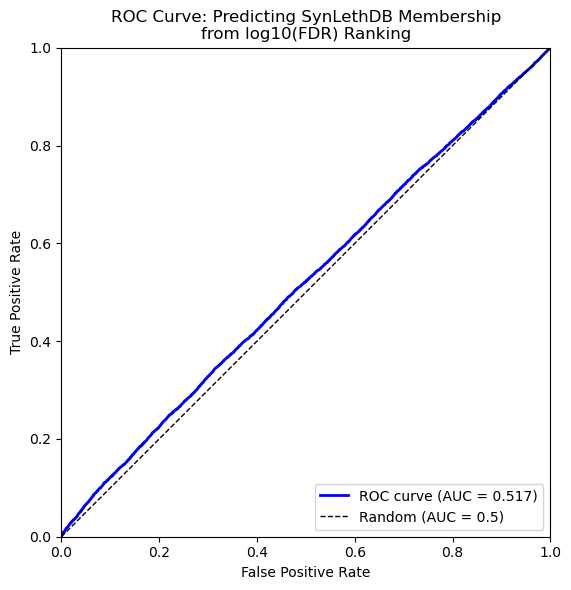

In [14]:
# Method 5: ROC-AUC (Rank-Based)
# Use your ranking score as a predictor of SynLethDB membership
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(ranked["in_synlethdb"], ranked["log10fdr_vae"])

print("=" * 60)
print("Method 5: ROC-AUC")
print("=" * 60)
print(f"\nAUC: {auc:.4f}")
print(f"  - 0.5 = random ranking")
print(f"  - 1.0 = perfect recovery of SynLethDB pairs")
print(f"  - >0.5 = SynLethDB pairs tend to have higher log10fdr_vae scores")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(ranked["in_synlethdb"], ranked["log10fdr_vae"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Predicting SynLethDB Membership\nfrom log10(FDR) Ranking')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

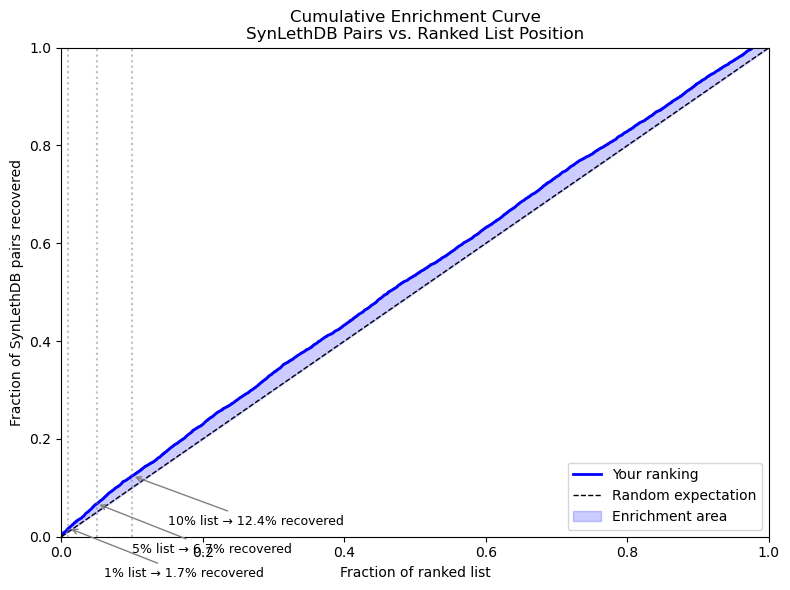


Cumulative recovery at key thresholds:
  Top   1.0% of list (297,965 pairs):   1.7% of SynLethDB pairs recovered (167 pairs)
  Top   5.0% of list (1,489,825 pairs):   6.7% of SynLethDB pairs recovered (645 pairs)
  Top  10.0% of list (2,979,651 pairs):  12.4% of SynLethDB pairs recovered (1,191 pairs)
  Top  25.0% of list (7,449,129 pairs):  28.1% of SynLethDB pairs recovered (2,692 pairs)
  Top  50.0% of list (14,898,259 pairs):  53.4% of SynLethDB pairs recovered (5,114 pairs)


In [15]:
# Method 7: Cumulative Enrichment Curve
# Visualize how SynLethDB pairs accumulate as you go down your ranked list

ranked["cumulative_synlethdb"] = ranked["in_synlethdb"].cumsum()
ranked["cumulative_frac"] = ranked["cumulative_synlethdb"] / len(synlethdb_in_universe)
ranked["list_frac"] = ranked["rank"] / len(ranked)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ranked["list_frac"], ranked["cumulative_frac"], 'b-', linewidth=2, label='Your ranking')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random expectation')
ax.fill_between(ranked["list_frac"], ranked["cumulative_frac"], ranked["list_frac"], 
                alpha=0.2, color='blue', label='Enrichment area')

ax.set_xlabel('Fraction of ranked list')
ax.set_ylabel('Fraction of SynLethDB pairs recovered')
ax.set_title('Cumulative Enrichment Curve\nSynLethDB Pairs vs. Ranked List Position')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add annotation for key points
for frac in [0.01, 0.05, 0.10]:
    idx = int(frac * len(ranked)) - 1
    if idx >= 0:
        recovery = ranked.iloc[idx]["cumulative_frac"]
        ax.axvline(x=frac, color='gray', linestyle=':', alpha=0.5)
        ax.annotate(f'{frac*100:.0f}% list → {recovery*100:.1f}% recovered', 
                    xy=(frac, recovery), xytext=(frac + 0.05, recovery - 0.1),
                    fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nCumulative recovery at key thresholds:")
for frac in [0.01, 0.05, 0.10, 0.25, 0.50]:
    idx = int(frac * len(ranked)) - 1
    if idx >= 0:
        recovery = ranked.iloc[idx]["cumulative_frac"]
        n_recovered = ranked.iloc[idx]["cumulative_synlethdb"]
        print(f"  Top {frac*100:5.1f}% of list ({idx+1:,} pairs): {recovery*100:5.1f}% of SynLethDB pairs recovered ({n_recovered:,} pairs)")

In [16]:
# Method 6: Precision at Top-K
# How many of your top-K pairs are in SynLethDB?

print("=" * 60)
print("Method 6: Precision@K")
print("=" * 60)

top_k_values = [100, 500, 1000, 5000, 10000, len(nominated)]
results = []

for k in top_k_values:
    top_k_pairs = set(ranked.head(k)["pair"])
    hits = len(top_k_pairs & synlethdb_in_universe)
    precision_at_k = hits / k
    
    # Calculate expected precision under random
    expected_precision = len(synlethdb_in_universe) / len(universe)
    fold_enrichment = precision_at_k / expected_precision if expected_precision > 0 else 0
    
    results.append({
        "K": k,
        "Hits": hits,
        "Precision@K": precision_at_k,
        "Expected (random)": expected_precision,
        "Fold enrichment": fold_enrichment
    })
    
    label = f" (= nominated set)" if k == len(nominated) else ""
    print(f"\nPrecision@{k:,}{label}:")
    print(f"  Hits: {hits:,} / {k:,}")
    print(f"  Precision: {precision_at_k:.4f} ({precision_at_k*100:.2f}%)")
    print(f"  Expected (random): {expected_precision:.4f} ({expected_precision*100:.2f}%)")
    print(f"  Fold enrichment: {fold_enrichment:.2f}x")

precision_df = pd.DataFrame(results)
precision_df

Method 6: Precision@K

Precision@100:
  Hits: 7 / 100
  Precision: 0.0700 (7.00%)
  Expected (random): 0.0003 (0.03%)
  Fold enrichment: 217.17x

Precision@500:
  Hits: 12 / 500
  Precision: 0.0240 (2.40%)
  Expected (random): 0.0003 (0.03%)
  Fold enrichment: 74.46x

Precision@1,000:
  Hits: 17 / 1,000
  Precision: 0.0170 (1.70%)
  Expected (random): 0.0003 (0.03%)
  Fold enrichment: 52.74x

Precision@5,000:
  Hits: 21 / 5,000
  Precision: 0.0042 (0.42%)
  Expected (random): 0.0003 (0.03%)
  Fold enrichment: 13.03x

Precision@10,000:
  Hits: 30 / 10,000
  Precision: 0.0030 (0.30%)
  Expected (random): 0.0003 (0.03%)
  Fold enrichment: 9.31x

Precision@22,772 (= nominated set):
  Hits: 37 / 22,772
  Precision: 0.0016 (0.16%)
  Expected (random): 0.0003 (0.03%)
  Fold enrichment: 5.04x


,K,Hits,Precision@K,Expected (random),Fold enrichment
0,100,7,0.070000,0.000322,217.172510
1,500,12,0.024000,0.000322,74.459146
2,1000,17,0.017000,0.000322,52.741895
3,5000,21,0.004200,0.000322,13.030351
4,10000,30,0.003000,0.000322,9.307393
5,22772,37,0.001625,0.000322,5.040892


In [17]:
# Summary of all comparison methods
print("=" * 70)
print("SUMMARY: SL List Comparison with SynLethDB")
print("=" * 70)

print(f"\n{'Dataset Statistics':^70}")
print("-" * 70)
print(f"  Universe (all tested pairs):     {len(universe):>15,}")
print(f"  Nominated SL pairs:              {len(nominated):>15,}")
print(f"  SynLethDB pairs (total):         {len(synlethdb):>15,}")
print(f"  SynLethDB pairs in universe:     {len(synlethdb_in_universe):>15,}")
print(f"  Overlap (nominated ∩ SynLethDB): {len(nominated & synlethdb_in_universe):>15,}")

print(f"\n{'Enrichment Tests':^70}")
print("-" * 70)
print(f"  Fisher's Exact Test:")
print(f"    Odds ratio:                    {odds_ratio:>15.2f}")
print(f"    P-value:                       {pvalue_fisher:>15.2e}")
print(f"  Hypergeometric Test:")
print(f"    P-value:                       {pvalue_hypergeom:>15.2e}")

print(f"\n{'Classification Metrics (SynLethDB as ground truth)':^70}")
print("-" * 70)
print(f"  Precision:                       {precision:>15.4f}")
print(f"  Recall:                          {recall:>15.4f}")
print(f"  F1 Score:                        {f1:>15.4f}")

print(f"\n{'Ranking Quality':^70}")
print("-" * 70)
print(f"  Mann-Whitney U P-value:          {pvalue_mwu:>15.2e}")
print(f"  ROC-AUC:                         {auc:>15.4f}")

print(f"\n{'Precision@K':^70}")
print("-" * 70)
for _, row in precision_df.iterrows():
    k = int(row["K"])
    p = row["Precision@K"]
    fe = row["Fold enrichment"]
    print(f"  Precision@{k:<6,}:                {p:>10.4f}  ({fe:.1f}x enrichment)")

SUMMARY: SL List Comparison with SynLethDB

                          Dataset Statistics                          
----------------------------------------------------------------------
  Universe (all tested pairs):          29,693,687
  Nominated SL pairs:                       22,772
  SynLethDB pairs (total):                  37,536
  SynLethDB pairs in universe:               9,571
  Overlap (nominated ∩ SynLethDB):              29

                           Enrichment Tests                           
----------------------------------------------------------------------
  Fisher's Exact Test:
    Odds ratio:                               3.96
    P-value:                              1.19e-09
  Hypergeometric Test:
    P-value:                              1.19e-09

          Classification Metrics (SynLethDB as ground truth)          
----------------------------------------------------------------------
  Precision:                                0.0013
  Recall:              